# Import necessary libraries

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score
import warnings 

warnings.filterwarnings('ignore')  

In [39]:
# Step 1: Read the heart dataset

df = pd.read_csv('/Users/bernardelango/Downloads/heart_disease.csv')  # Replace 'heart_data.csv' with the actual filename

In [40]:
# Step 2: Exploratory Data Analysis (EDA)

print("Data Quality Check:")
print(df.info())  # Check data types and missing values

Data Quality Check:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   age              303 non-null    float64
 1   gender           303 non-null    float64
 2   cp               303 non-null    float64
 3   trestbps         303 non-null    float64
 4   chol             303 non-null    float64
 5   fbs              303 non-null    float64
 6   restecg          303 non-null    float64
 7   thalach          303 non-null    float64
 8   exang            303 non-null    float64
 9   oldpeak          303 non-null    float64
 10  slope            303 non-null    float64
 11  ca               299 non-null    float64
 12  thal             301 non-null    float64
 13  heart_diagnosis  303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB
None


In [41]:
# Step 2 (Continued): Handle missing values

imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

In [42]:
print("\nMissing Values:")
print(df.isnull().sum())  # Count missing values


Missing Values:
age                0
gender             0
cp                 0
trestbps           0
chol               0
fbs                0
restecg            0
thalach            0
exang              0
oldpeak            0
slope              0
ca                 4
thal               2
heart_diagnosis    0
dtype: int64


In [43]:
# Step 3: Transform categorical data
# Encode categorical variables using LabelEncoder
label_encoder = LabelEncoder()
X_imputed['gender'] = label_encoder.fit_transform(X_imputed['gender'])
X_imputed['cp'] = label_encoder.fit_transform(X_imputed['cp'])
X_imputed['fbs'] = label_encoder.fit_transform(X_imputed['fbs'])
X_imputed['restecg'] = label_encoder.fit_transform(X_imputed['restecg'])
X_imputed['exang'] = label_encoder.fit_transform(X_imputed['exang'])
X_imputed['slope'] = label_encoder.fit_transform(X_imputed['slope'])
X_imputed['thal'] = label_encoder.fit_transform(X_imputed['thal'])

In [44]:
# Step 4: Apply Logistic Regression model
# Split dataset into training set and test set

X_train, X_test, y_train, y_test = train_test_split(X_imputed, y, test_size=0.3, random_state=42)

# Create Logistic Regression model
logreg = LogisticRegression(max_iter=1000)

# Train the model using the training sets
logreg.fit(X_train, y_train)


LogisticRegression(max_iter=1000)

In [45]:
# Step 5: Print model results
# Predict the response for test dataset
y_pred = logreg.predict(X_test)

# Model Accuracy
print("\nModel Accuracy:", accuracy_score(y_test, y_pred))


Model Accuracy: 0.5824175824175825


In [46]:
# Step 6: Get the feature importance
feature_importance = logreg.coef_[0]
feature_names = X_imputed.columns

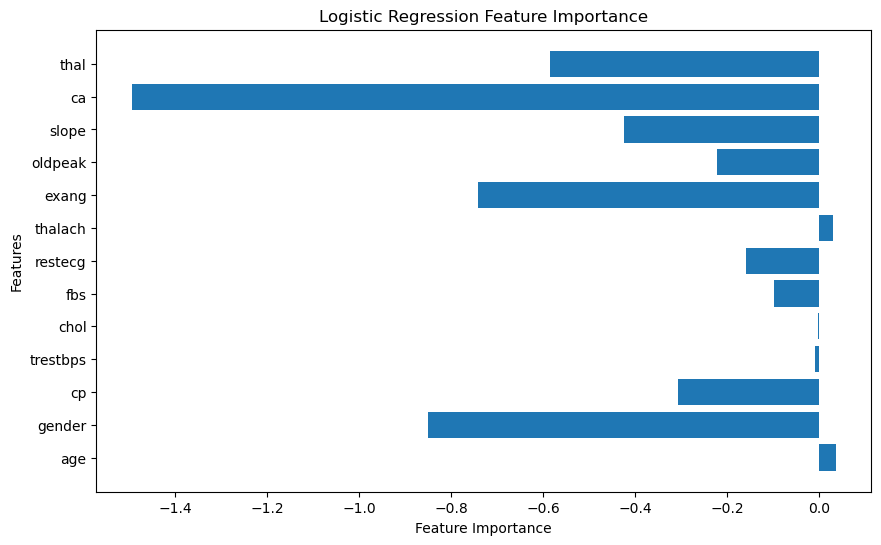

In [47]:
# Plotting feature importance
plt.figure(figsize=(10, 6))
plt.barh(feature_names, feature_importance)
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.title('Logistic Regression Feature Importance')
plt.show()